# Critical Patient Survival Prediction (SUPPORT2)


This notebook builds and evaluates a **Logistic Regression** model to predict **in-hospital mortality** (`hospdead`) from patient and clinical features in the SUPPORT2 dataset.


**Workflow**
- Import libraries
- Load dataset
- Exploratory data analysis (EDA)
- Preprocessing (leakage removal, imputation, encoding, scaling)
- Train/test split + model training
- Evaluation (metrics, confusion matrix, ROC curve)

In [46]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import json

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Machine Learning - Modeling
from sklearn.linear_model import LogisticRegression

# Machine Learning - Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

print("✓ Libraries imported successfully")


✓ Libraries imported successfully


## Load Dataset


Load the SUPPORT2 dataset from CSV and confirm the shape (rows/columns).

In [47]:
# Load dataset
df = pd.read_csv("support2-1.csv")

print(f"✓ Dataset loaded successfully")
print(f"Total patients: {df.shape[0]:,}")
print(f"Total variables: {df.shape[1]}")


✓ Dataset loaded successfully
Total patients: 9,105
Total variables: 48


## Exploratory Data Analysis (EDA)


This section quickly inspects the dataset structure and explores how key variables relate to the target (`hospdead`).


We will:
- Preview rows + check column types
- Explore correlations with the target (numeric features)
- Visualize basic distributions (age, disease group, target balance)
- Check missing values before preprocessing

In [48]:
print("First 5 rows of the dataset:")
df.head()

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names ({len(df.columns)} total):")
print(df.columns.tolist())

print("\nData type distribution:")
df.dtypes.value_counts()


First 5 rows of the dataset:
Dataset shape: (9105, 48)

Column names (48 total):
['ID', 'age', 'death', 'sex', 'hospdead', 'slos', 'd.time', 'dzgroup', 'dzclass', 'num.co', 'edu', 'income', 'scoma', 'charges', 'totcst', 'totmcst', 'avtisst', 'race', 'sps', 'aps', 'surv2m', 'surv6m', 'hday', 'diabetes', 'dementia', 'ca', 'prg2m', 'prg6m', 'dnr', 'dnrday', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'urine', 'adlp', 'adls', 'sfdm2', 'adlsc']

Data type distribution:


float64    31
int64       9
object      8
Name: count, dtype: int64

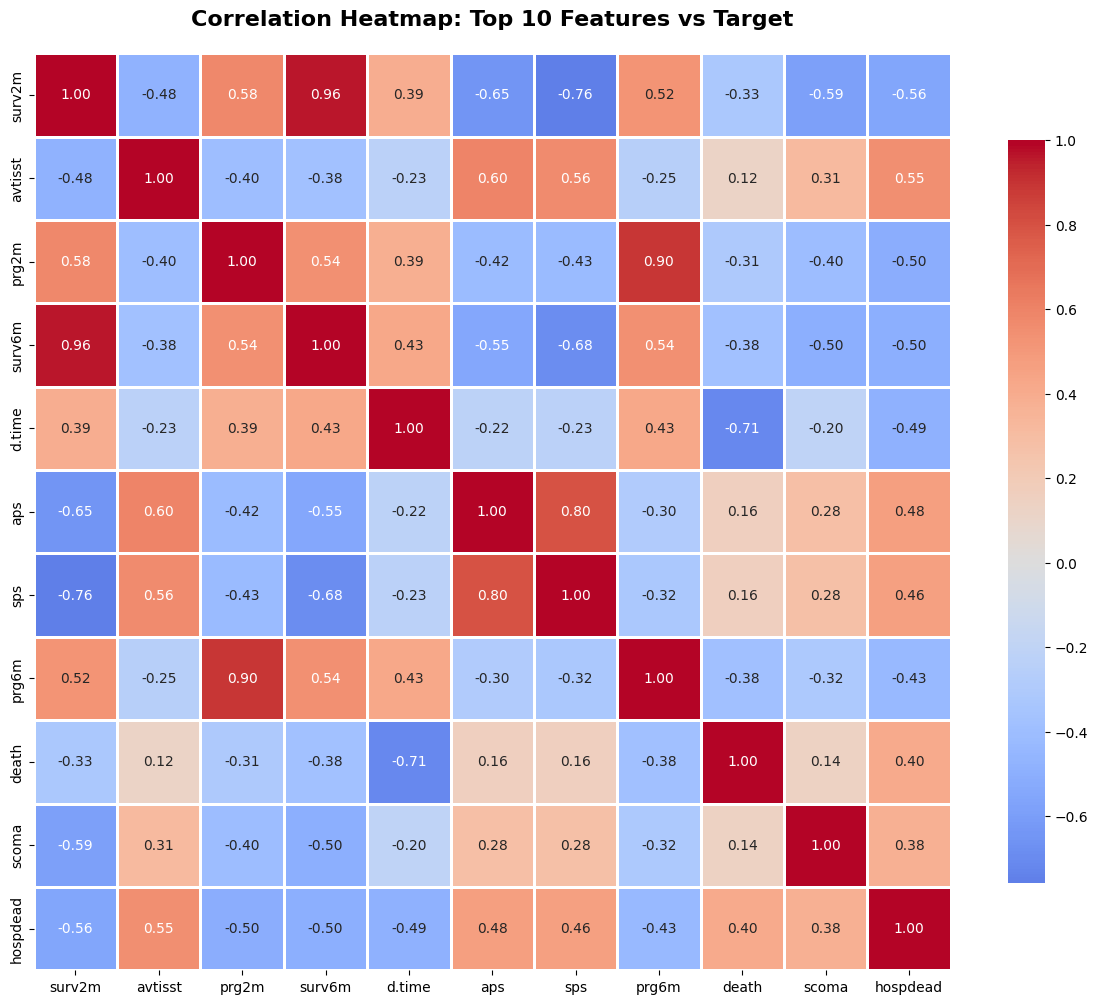

Top 10 Features Most Correlated with Target:
   1. surv2m         : 0.5581
   2. avtisst        : 0.5525
   3. prg2m          : 0.5040
   4. surv6m         : 0.4981
   5. d.time         : 0.4866
   6. aps            : 0.4759
   7. sps            : 0.4626
   8. prg6m          : 0.4302
   9. death          : 0.4048
  10. scoma          : 0.3796


In [65]:

# Select numeric columns only
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate correlation with target
if 'hospdead' in numeric_df.columns:
    corr_with_target = numeric_df.corr()['hospdead'].abs().sort_values(ascending=False)
    
    # Get top 10 features (excluding target itself)
    top_features = corr_with_target.drop('hospdead').head(10).index.tolist()
    top_features.append('hospdead')  # Add target back
    
    # Create correlation matrix for top features
    corr_matrix = numeric_df[top_features].corr()
    
    # Plot heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, 
                cbar_kws={"shrink": 0.8})
    plt.title('Correlation Heatmap: Top 10 Features vs Target', 
              fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('correlation_heatmap_top10.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Top 10 Features Most Correlated with Target:")
    for i, (feat, corr) in enumerate(corr_with_target.drop('hospdead').head(10).items(), 1):
        print(f"  {i:2d}. {feat:15s}: {corr:.4f}")


### Correlation With Target (Numeric Features)


We compute correlations between numeric features and `hospdead` to identify variables most associated with mortality. This is **exploratory** and helps guide feature understanding.


In this step we:
- Select only numeric columns
- Compute absolute correlation with `hospdead`
- Plot a heatmap of the top correlated features
- Print the top 10 correlations

### Distributions: Age, Disease Group, Target Balance


These quick plots help us understand the patient population and the class balance of the prediction task (`hospdead`).

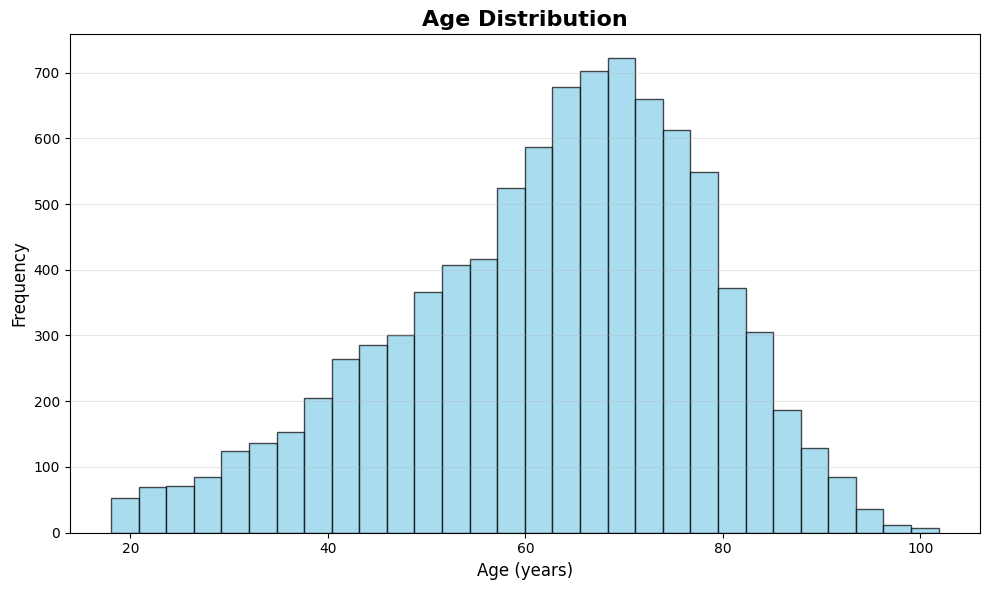

Age Statistics:
  Mean: 62.65 years
  Median: 64.86 years
  Std Dev: 15.59 years
  Range: 18 - 102 years


In [ ]:

# Age distribution
plt.figure(figsize=(10, 6))
plt.hist(df['age'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Age Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistics
print(f"Age Statistics:")
print(f"  Mean: {df['age'].mean():.2f} years")
print(f"  Median: {df['age'].median():.2f} years")
print(f"  Std Dev: {df['age'].std():.2f} years")
print(f"  Range: {df['age'].min():.0f} - {df['age'].max():.0f} years")


#### Age Distribution


Visualize the distribution of patient ages and print basic summary statistics (mean/median/std/range).

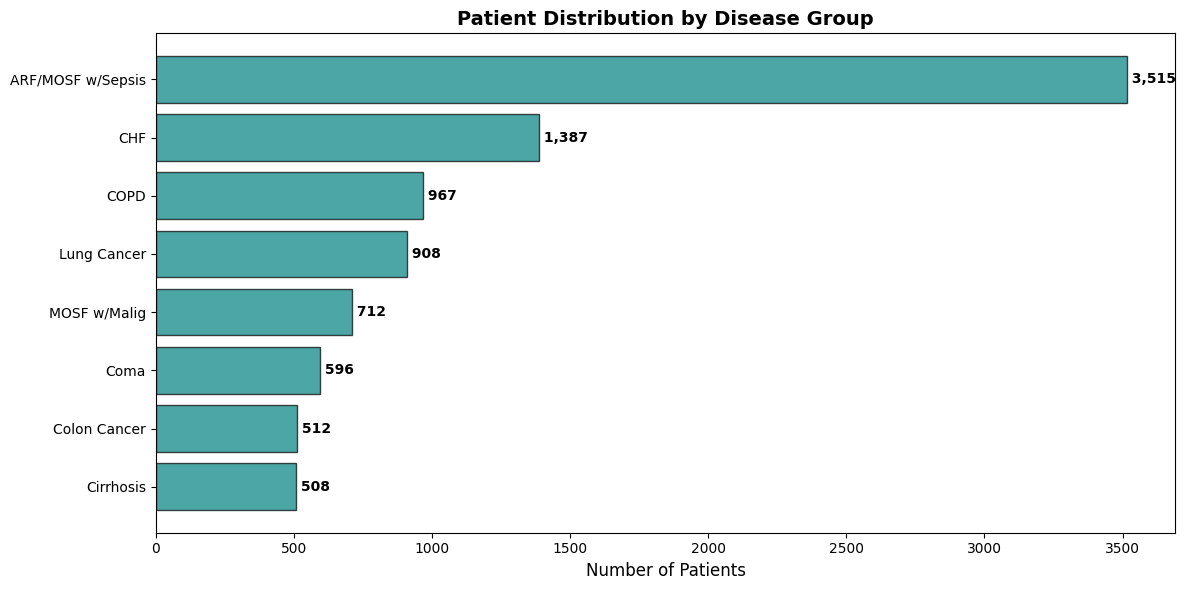

In [69]:
if 'dzgroup' in df.columns:
    plt.figure(figsize=(12, 6))
    
    disease_counts = df['dzgroup'].value_counts()
    bars = plt.barh(disease_counts.index, disease_counts.values, 
                    color='teal', edgecolor='black', alpha=0.7)
    
    plt.xlabel('Number of Patients', fontsize=12)
    plt.title('Patient Distribution by Disease Group', 
             fontweight='bold', fontsize=14)
    plt.gca().invert_yaxis()
    
    # Add count labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2.,
                f' {int(width):,}',
                ha='left', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('disease_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()



#### Disease Group Breakdown (`dzgroup`)


Show how patients are distributed across disease groups (if the column exists). This is helpful context for dataset composition.

In [ ]:
TARGET = 'hospdead'
y = df[TARGET]

print(f"Target variable: {TARGET}")
print(f"\nClass distribution:")
print(y.value_counts().sort_index())
print(f"\nClass distribution (percentage):")
print(y.value_counts(normalize=True).sort_index() * 100)


#### Target Variable Inspection (`hospdead`)


Check the class distribution of the target to understand how imbalanced the mortality prediction task is.

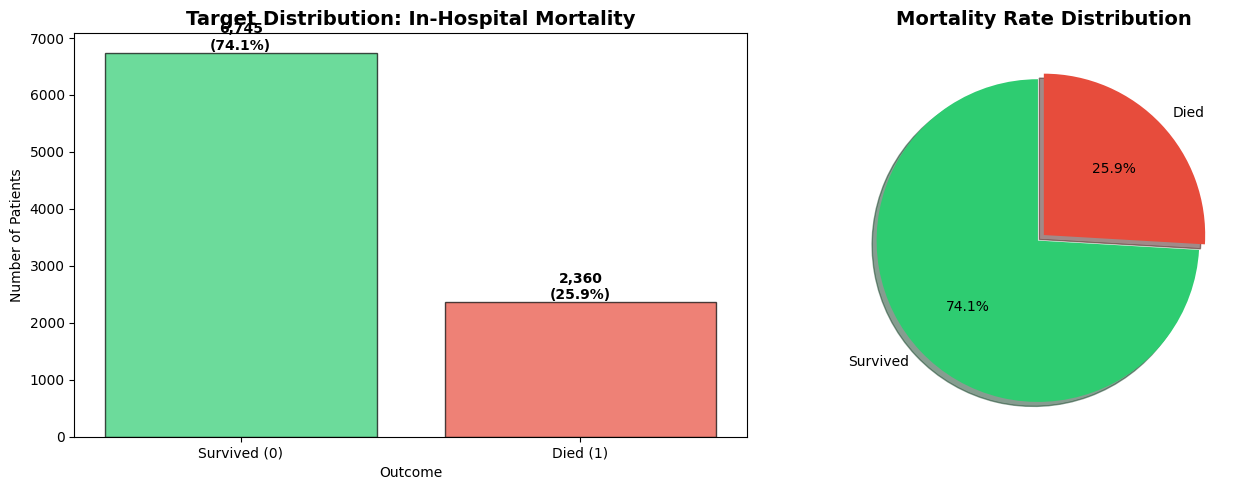

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df['hospdead'].value_counts().sort_index()
bars = axes[0].bar(['Survived (0)', 'Died (1)'], counts.values, 
                   color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
axes[0].set_title('Target Distribution: In-Hospital Mortality', 
                  fontweight='bold', fontsize=14)
axes[0].set_ylabel('Number of Patients')
axes[0].set_xlabel('Outcome')

# Add count and percentage labels
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}\n({height/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Survived', 'Died'], 
           colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
           startangle=90, explode=(0.05, 0), shadow=True)
axes[1].set_title('Mortality Rate Distribution', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


### Missing Values Check


Before modeling, we inspect missingness to understand how much imputation is needed and which variables are most affected.

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_%': missing_pct.values
}).sort_values('Missing_Count', ascending=False)

print("Top 15 columns with missing values:")
print(missing_df.head(15).to_string(index=False))

total_missing = missing.sum()
total_cells = df.shape[0] * df.shape[1]
print(f"\n✓ Total missing cells: {total_missing:,} ({total_missing/total_cells*100:.2f}% of dataset)")



Top 15 columns with missing values:
 Column  Missing_Count  Missing_%
   adlp           5641      61.95
  urine           4862      53.40
glucose           4500      49.42
    bun           4352      47.80
totmcst           3475      38.17
    alb           3372      37.03
 income           2982      32.75
   adls           2867      31.49
   bili           2601      28.57
   pafi           2325      25.54
     ph           2284      25.09
  prg2m           1649      18.11
    edu           1634      17.95
  prg6m           1633      17.94
  sfdm2           1400      15.38

✓ Total missing cells: 47,110 (10.78% of dataset)


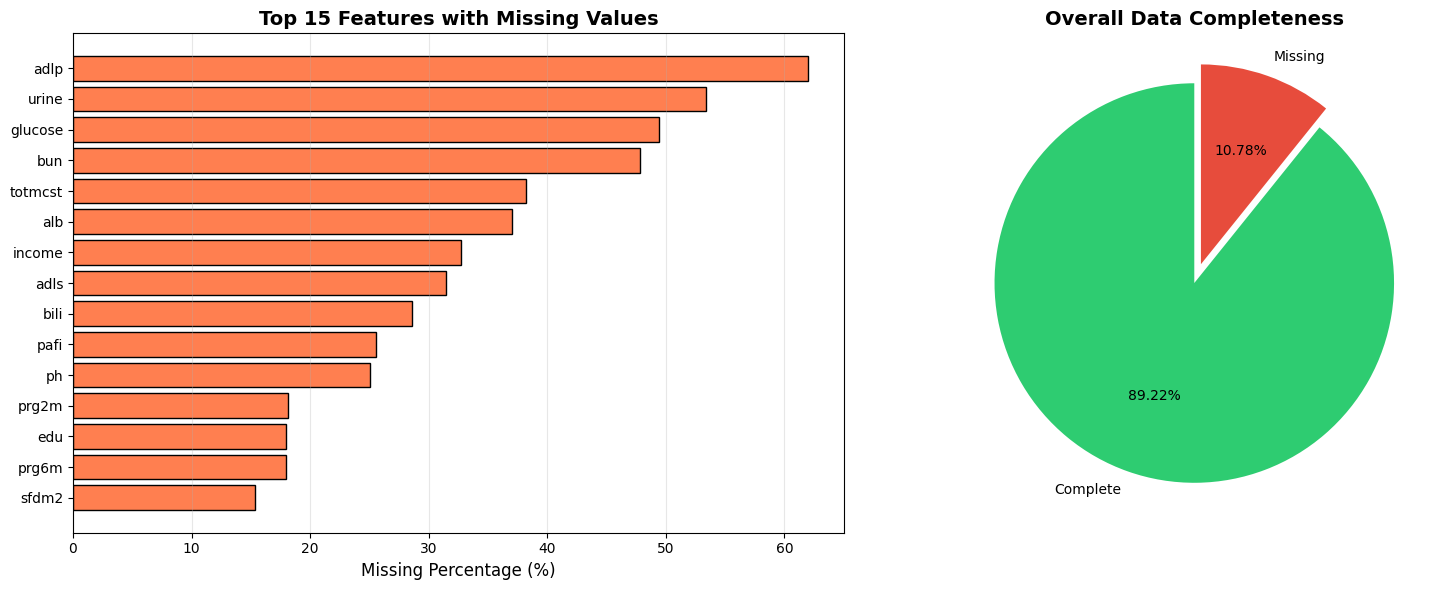

In [67]:
# Calculate missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100)
missing_df = pd.DataFrame({
    'Feature': missing.index,
    'Missing_Count': missing.values,
    'Missing_%': missing_pct.values
}).sort_values('Missing_Count', ascending=False)

# Top 15 with missing values
top_missing = missing_df[missing_df['Missing_Count'] > 0].head(15)

if len(top_missing) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar chart
    axes[0].barh(top_missing['Feature'], top_missing['Missing_%'], 
                color='coral', edgecolor='black')
    axes[0].set_xlabel('Missing Percentage (%)', fontsize=12)
    axes[0].set_title('Top 15 Features with Missing Values', 
                     fontweight='bold', fontsize=14)
    axes[0].invert_yaxis()
    axes[0].grid(axis='x', alpha=0.3)
    
    # Overall missing data pie
    total_missing = missing.sum()
    total_complete = (len(df) * len(df.columns)) - total_missing
    axes[1].pie([total_complete, total_missing], 
               labels=['Complete', 'Missing'],
               colors=['#2ecc71', '#e74c3c'],
               autopct='%1.2f%%', startangle=90, explode=(0, 0.1))
    axes[1].set_title('Overall Data Completeness', fontweight='bold', fontsize=14)
    
    plt.tight_layout()
    plt.savefig('missing_values_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()


### Missing Values Visualization


Plot the top features with missing data and show an overall completeness summary. This helps justify the imputation strategy used later.

## Data Preprocessing


From this point, we prepare the dataset for modeling by:
- Removing columns that would leak outcome information
- Separating features (`X`) and target (`y`)
- Imputing missing values
- Encoding categorical variables
- Splitting into train/test sets
- Scaling numeric features (required for Logistic Regression to behave well)

In [52]:
# Remove leakage and administrative columns
leakage_cols = [
    'death',      # Alternative target (long-term mortality)
    'slos',       # Length of stay (known only post-discharge)
    'd.time',     # Follow-up time (outcome-dependent)
    'surv2m',     # Survival estimate (derived from outcome)
    'surv6m',     # Survival estimate (derived from outcome)
    'prg2m',      # Physician prognosis (may be outcome-informed)
    'prg6m',      # Physician prognosis (may be outcome-informed)
    'dnr',        # DNR order (may be outcome-dependent)
    'dnrday',     # DNR timing (may be outcome-dependent)
    'sfdm2'       # Functional disability at 2 months (future information)
]

# Drop columns if they exist
df_clean = df.drop(columns=[c for c in leakage_cols if c in df.columns])

print(f"✓ Removed {len([c for c in leakage_cols if c in df.columns])} leakage columns")
print(f"Remaining features: {df_clean.shape[1] - 1}")  # -1 for target


y = df_clean[TARGET]
X = df_clean.drop(columns=[TARGET])

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")



✓ Removed 10 leakage columns
Remaining features: 37
Features (X): (9105, 37)
Target (y): (9105,)


### Identify Feature Types + Impute Missing Values


We split predictors into **numeric** and **categorical** columns, then handle missing values:
- Numeric features: median imputation (robust to outliers)
- Categorical features: mode imputation (most frequent category)

In [53]:
# Identify numeric and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

print(f"Numeric features: {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")

# Impute missing values
X_imputed = X.copy()

# Numeric: median imputation (robust to outliers)
for col in num_cols:
    if X_imputed[col].isnull().any():
        X_imputed[num_cols] = X_imputed[num_cols].fillna(
    X_imputed[num_cols].median()
)

# Categorical: mode imputation
for col in cat_cols:
    if X_imputed[col].isnull().any():
        X_imputed[cat_cols] = X_imputed[cat_cols].fillna(
    X_imputed[cat_cols].mode().iloc[0]
)

print(f"\n✓ Missing values imputed")
print(f"Remaining missing values: {X_imputed.isnull().sum().sum()}")


Numeric features: 31
Categorical features: 6

✓ Missing values imputed
Remaining missing values: 0


### Encode Categorical Variables


Convert categorical variables into numeric features using **one-hot encoding** so Logistic Regression can train on them. We use `drop_first=True` to reduce redundant dummy columns.

In [54]:
# One-hot encode categorical features
X_encoded = pd.get_dummies(X_imputed, drop_first=True)

print(f"✓ Categorical variables encoded")
print(f"Final feature count: {X_encoded.shape[1]}")


✓ Categorical variables encoded
Final feature count: 51


### Train/Test Split


Split the dataset into training and test sets (80/20). We use `stratify=y` to preserve the same class balance (survived vs died) in both sets.

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True) * 100)

print(f"\nClass distribution in test set:")
print(y_test.value_counts(normalize=True) * 100)


Training set: 7,284 samples (80.0%)
Test set: 1,821 samples (20.0%)

Class distribution in training set:
hospdead
0    74.080176
1    25.919824
Name: proportion, dtype: float64

Class distribution in test set:
hospdead
0    74.080176
1    25.919824
Name: proportion, dtype: float64


### Feature Scaling


Standardize features using **StandardScaler** (zero mean, unit variance). This is important for Logistic Regression so coefficients are on comparable scales and optimization is stable.

In [56]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled using StandardScaler")


✓ Features scaled using StandardScaler


## Model Training


Train a **Logistic Regression** classifier using the scaled training set, then generate predictions and predicted probabilities on the test set.

In [57]:
# Initialize model
lr = LogisticRegression(max_iter=2000, random_state=42)

# Train model
lr.fit(X_train_scaled, y_train)

print("✓ Logistic Regression model trained successfully")

y_pred = lr.predict(X_test_scaled)
y_proba = lr.predict_proba(X_test_scaled)[:, 1]



✓ Logistic Regression model trained successfully


## Model Evaluation


Evaluate the trained model on the held-out test set using standard classification metrics and diagnostic plots.

In [58]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print("LOGISTIC REGRESSION - PERFORMANCE METRICS")
print("="*50)
print(f"Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}")


LOGISTIC REGRESSION - PERFORMANCE METRICS
Accuracy:  0.8671 (86.71%)
Precision: 0.7889
Recall:    0.6653
F1-Score:  0.7218
ROC-AUC:   0.9159


### Performance Metrics


Compute key metrics on the test set:
- Accuracy
- Precision, Recall, F1-score
- ROC-AUC (uses predicted probabilities)


Confusion Matrix:
                Predicted
              Survived  Died
Actual Survived   1265     84
       Died        158    314


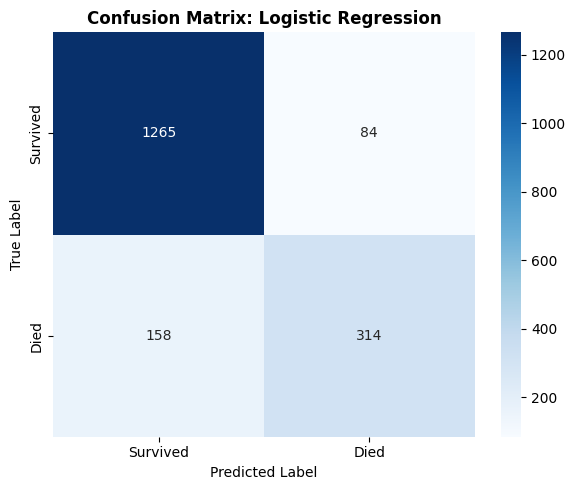

In [59]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(f"                Predicted")
print(f"              Survived  Died")
print(f"Actual Survived  {cm[0][0]:5d}  {cm[0][1]:5d}")
print(f"       Died      {cm[1][0]:5d}  {cm[1][1]:5d}")

# Visualize confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Survived', 'Died'],
            yticklabels=['Survived', 'Died'])
plt.title('Confusion Matrix: Logistic Regression', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


### Confusion Matrix


Show how many predictions fall into each category (true/false positives/negatives), then visualize the confusion matrix as a heatmap.

In [60]:
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))



Detailed Classification Report:
              precision    recall  f1-score   support

    Survived       0.89      0.94      0.91      1349
        Died       0.79      0.67      0.72       472

    accuracy                           0.87      1821
   macro avg       0.84      0.80      0.82      1821
weighted avg       0.86      0.87      0.86      1821



### Classification Report


Print precision/recall/F1 per class (Survived vs Died) plus macro/weighted averages for a more detailed view than overall accuracy.

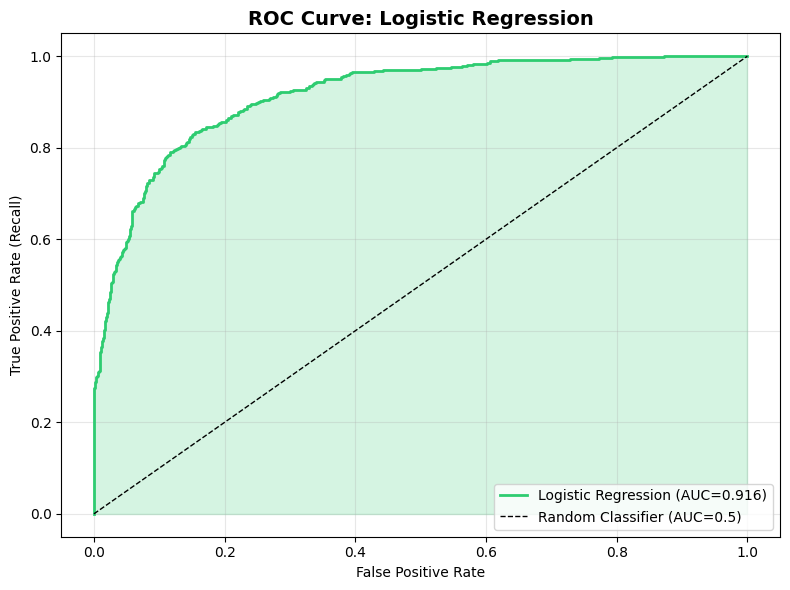

In [61]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2ecc71', linewidth=2, 
         label=f'Logistic Regression (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC=0.5)')
plt.fill_between(fpr, tpr, alpha=0.2, color='#2ecc71')
plt.title('ROC Curve: Logistic Regression', fontweight='bold', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### ROC Curve


Plot the ROC curve to visualize the tradeoff between True Positive Rate (recall) and False Positive Rate across thresholds. The AUC summarizes overall ranking performance.

In [62]:
# Summary Statisitics
summary = pd.DataFrame({
    'Metric': [
        'Total Patients',
        'Total Features',
        'Numeric Features',
        'Categorical Features',
        'Survived Count',
        'Died Count',
        'Survival Rate (%)'
    ],
    'Value': [
        df.shape[0],
        df.shape[1],
        len(num_cols),
        len(cat_cols),
        (df['hospdead'] == 0).sum(),
        (df['hospdead'] == 1).sum(),
        round((df['hospdead'] == 0).sum() / len(df) * 100, 2)
    ]
})

# summary.to_csv('dataset_summary.csv', index=False)
# print("Summary saved to: dataset_summary.csv")
summary



,Metric,Value
0,Total Patients,9105.00
1,Total Features,48.00
2,Numeric Features,31.00
3,Categorical Features,6.00
4,Survived Count,6745.00
5,Died Count,2360.00
6,Survival Rate (%),74.08
